<a href="https://colab.research.google.com/github/zopvan/mlStrkanalyst/blob/main/KNN_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/UTS_machine_learning/KNN/

brain_stroke.csv  KNN_UTS.ipynb


In [ ]:
file_path = '/content/drive/MyDrive/UTS_machine_learning/KNN/brain_stroke.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    raise SystemExit

In [ ]:
df.shape

(4981, 11)

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


Audit data

In [ ]:
# 1. Jumlah Baris dan Kolom
print(f"Bentuk dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

Bentuk dataset: 4981 baris, 11 kolom


In [ ]:
# 2. Tipe Data
print("\n--- Tipe Data ---")
print(df.dtypes)


--- Tipe Data ---
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [ ]:
# 3 & 7. Jumlah Kelas Target dan Distribusi Kelas
print("\n--- Distribusi Kelas Target (Stroke) ---")
print(df['stroke'].value_counts())


--- Distribusi Kelas Target (Stroke) ---
stroke
0    4733
1     248
Name: count, dtype: int64


In [ ]:
# 4. Deteksi Missing Values
print("\n--- Missing Value per Kolom ---")
print(df.isnull().sum())


--- Missing Value per Kolom ---
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [ ]:
# 5. Deteksi Duplikat
print(f"\n--- Jumlah Baris Duplikat: {df.duplicated().sum()} ---")


--- Jumlah Baris Duplikat: 0 ---


In [ ]:
# 6. Deteksi Outlier (menggunakan aturan IQR)
num_cols = ['age', 'avg_glucose_level', 'bmi']
print("\n--- Deteksi Outlier ---")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"Jumlah outlier pada atribut {col}: {outliers}")


--- Deteksi Outlier ---
Jumlah outlier pada atribut age: 0
Jumlah outlier pada atribut avg_glucose_level: 602
Jumlah outlier pada atribut bmi: 43


### Data Preprocessing

In [ ]:
# --- A. PENGHAPUSAN DUPLIKAT ---
# Menghapus baris yang identik
df.drop_duplicates(inplace=True)
print(f"Jumlah baris setelah penghapusan duplikat: {df.shape[0]}")

Jumlah baris setelah penghapusan duplikat: 4981


In [ ]:
# --- B. IMPUTASI (Jika ada missing value) ---
# Based on previous audit, there are no missing values. If there were, this code would fill them.
# Kolom numerik diisi dengan Median (Contoh jika 'bmi' memiliki missing value)
# df['bmi'].fillna(df['bmi'].median(), inplace=True)

# --- C. STRATEGI OUTLIER (Winsorization/Capping) ---
# Membatasi nilai ekstrim agar tidak merusak model KNN/SVM
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
    print(f"Outliers for {col} capped between {lower_bound:.2f} and {upper_bound:.2f}")

cap_outliers(df, 'avg_glucose_level')
cap_outliers(df, 'bmi')

Outliers for avg_glucose_level capped between 22.29 and 168.81
Outliers for bmi capped between 10.35 and 45.95


In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- G. HANDLING IMBALANCE CLASS (SMOTE) ---
from imblearn.over_sampling import SMOTE
import pandas as pd # Import pandas to use Series

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Distribusi target pada data training sebelum SMOTE:\n{pd.Series(y_train).value_counts()}")
print(f"Distribusi target setelah SMOTE:\n{pd.Series(y_train_res).value_counts()}")

Distribusi target pada data training sebelum SMOTE:
0    3316
1     170
Name: count, dtype: int64
Distribusi target setelah SMOTE:
0    3316
1    3316
Name: count, dtype: int64


In [ ]:
print("\nMelatih model K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)


Melatih model K-Nearest Neighbors...


KNeighborsClassifier(n_neighbors=3)

In [ ]:
# --- Evaluasi Model K-Nearest Neighbors ---
y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAkurasi Model K-Nearest Neighbors: {accuracy_knn * 100:.2f}%")

print("\nClassification Report (K-Nearest Neighbors):")
target_names_list = [str(c) for c in le.classes_]
print(classification_report(y_test, y_pred_knn, target_names=target_names_list))

cm_knn = confusion_matrix(y_test, y_pred_knn) # Define cm_knn here for the next cell

# --- Evaluasi Baseline menggunakan DummyClassifier ---
X_tr_base, X_te_base, y_tr_base, y_te_base = train_test_split(X_encoded, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_tr_base, y_tr_base)
y_pred_dummy = dummy.predict(X_te_base)

print("\n--- Laporan Evaluasi Baseline Sederhana ---")
print(classification_report(y_te_base, y_pred_dummy, zero_division=0))
print("Kesimpulan: Recall untuk penderita Stroke adalah 0.00. Model eksperimen kita wajib melampaui metrik ini.")


Akurasi Model K-Nearest Neighbors: 93.58%

Classification Report (K-Nearest Neighbors):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1417
           1       0.05      0.01      0.02        78

    accuracy                           0.94      1495
   macro avg       0.50      0.50      0.49      1495
weighted avg       0.90      0.94      0.92      1495


--- Laporan Evaluasi Baseline Sederhana ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1421
           1       0.00      0.00      0.00        74

    accuracy                           0.95      1495
   macro avg       0.48      0.50      0.49      1495
weighted avg       0.90      0.95      0.93      1495

Kesimpulan: Recall untuk penderita Stroke adalah 0.00. Model eksperimen kita wajib melampaui metrik ini.


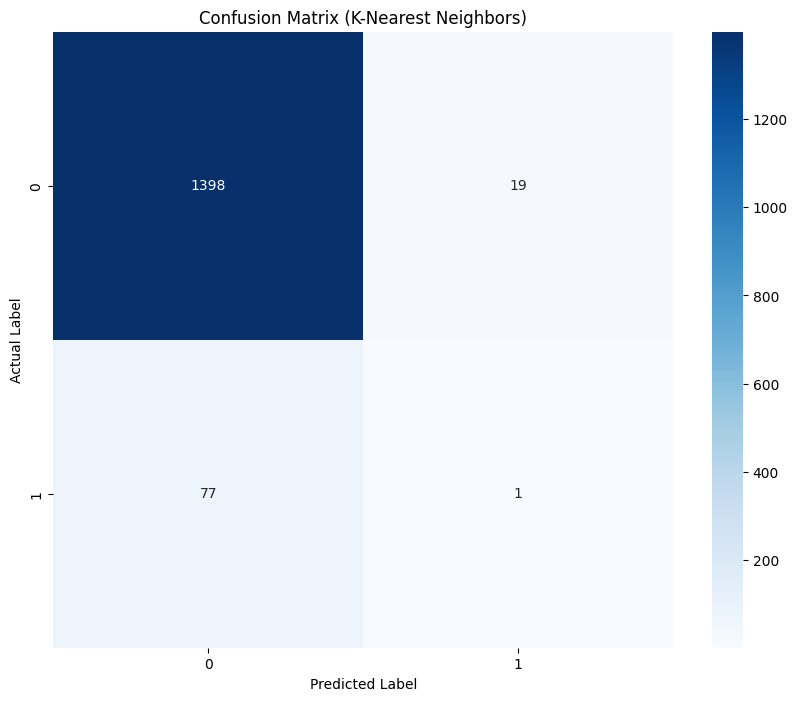

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
class_names = le.classes_
cm_df_knn = pd.DataFrame(cm_knn, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_knn, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix (K-Nearest Neighbors)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
new_data = pd.DataFrame([
    {
        'gender': 'Male',
        'age': 67.0,
        'hypertension': 0,
        'heart_disease': 1,
        'ever_married': 'Yes',
        'work_type': 'Private',
        'Residence_type': 'Urban',
        'avg_glucose_level': 228.69,
        'bmi': 36.6,
        'smoking_status': 'formerly smoked'
    },
    {
        'gender': 'Female',
        'age': 25.0,
        'hypertension': 0,
        'heart_disease': 0,
        'ever_married': 'No',
        'work_type': 'Govt_job',
        'Residence_type': 'Rural',
        'avg_glucose_level': 85.50,
        'bmi': 22.0,
        'smoking_status': 'never smoked'
    }
])

new_data_encoded = pd.get_dummies(new_data, drop_first=True)

missing_cols = set(X_encoded.columns) - set(new_data_encoded.columns)
for c in missing_cols:
    new_data_encoded[c] = 0

new_data_encoded = new_data_encoded[X_encoded.columns]

new_data_scaled = scaler.transform(new_data_encoded)

new_predictions_encoded = knn_model.predict(new_data_scaled)

new_predictions_labels = le.inverse_transform(new_predictions_encoded)

print("\nData Baru Sebelum Encoding dan Scaling:")
display(new_data)

print("\nHasil Prediksi Risiko Stroke (0 = Tidak, 1 = Ya):")
for i, prediction in enumerate(new_predictions_labels):
    status = "Risiko Stroke" if prediction == 1 else "Tidak Risiko Stroke"
    print(f"Data Baru {i+1}: {prediction} ({status})")


Data Baru Sebelum Encoding dan Scaling:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Female,25.0,0,0,No,Govt_job,Rural,85.50,22.0,never smoked



Hasil Prediksi Risiko Stroke (0 = Tidak, 1 = Ya):
Data Baru 1: 0 (Tidak Risiko Stroke)
Data Baru 2: 0 (Tidak Risiko Stroke)


In [ ]:
import gradio as gr
import pandas as pd

def predict_stroke(gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status):
    try:
        gender_map = {"Laki-laki": "Male", "Perempuan": "Female"}
        married_map = {"Pernah Menikah": "Yes", "Belum Pernah Menikah": "No"}
        residence_map = {"Perkotaan": "Urban", "Pedesaan": "Rural"}
        status_map = {"Ya": 1, "Tidak": 0}

        input_data = pd.DataFrame({
            'gender': [gender_map.get(gender)],
            'age': [age],
            'hypertension': [status_map.get(hypertension)],
            'heart_disease': [status_map.get(heart_disease)],
            'ever_married': [married_map.get(ever_married)],
            'work_type': [work_type],
            'Residence_type': [residence_map.get(Residence_type)],
            'avg_glucose_level': [avg_glucose_level],
            'bmi': [bmi],
            'smoking_status': [smoking_status]
        })

        input_encoded = pd.get_dummies(input_data)
        input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)
        input_scaled = scaler.transform(input_encoded)

        prediction = knn_model.predict(input_scaled)[0]
        prob = knn_model.predict_proba(input_scaled)[0][1]

        if prediction == 1:
            return f"Hasil: Risiko Tinggi Stroke (Tingkat Keyakinan: {prob:.2%})"
        else:
            return f"Hasil: Risiko Rendah Stroke (Tingkat Keyakinan: {prob:.2%})"

    except Exception as e:
        return f"Terjadi kesalahan pada Gradio: {e}"

work_choices = df['work_type'].unique().tolist()
smoke_choices = df['smoking_status'].unique().tolist()

interface = gr.Interface(
    fn=predict_stroke,
    inputs=[
        gr.Dropdown(["Laki-laki", "Perempuan"], label="Jenis Kelamin"),
        gr.Slider(0, 100, label="Umur", value=30),
        gr.Dropdown(["Ya", "Tidak"], label="Memiliki Hipertensi?"),
        gr.Dropdown(["Ya", "Tidak"], label="Memiliki Penyakit Jantung?"),
        gr.Dropdown(["Pernah Menikah", "Belum Pernah Menikah"], label="Status Pernikahan"),
        gr.Dropdown(work_choices, label="Tipe Pekerjaan"),
        gr.Dropdown(["Perkotaan", "Pedesaan"], label="Tipe Tempat Tinggal"),
        gr.Number(label="Kadar Glukosa (mg/dL)", value=100),
        gr.Number(label="BMI", value=22),
        gr.Dropdown(smoke_choices, label="Status Merokok")
    ],
    outputs="text",
    title="Sistem Prediksi Risiko Stroke",
    description="Silakan isi data kesehatan untuk analisis risiko berdasarkan model KNN."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d26b7a132e2e431f7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
